# Algorithmic complexity: asymptotic growth and Big-O notation

**Goal.** Understand how algorithm cost is analysed as input size grows, and distinguish between time measured on a particular machine and asymptotic complexity.

Algorithmic complexity studies a cost function $T(n)$, where $n$ denotes input size and $T(n)$ counts resources such as elementary operations, comparisons, memory accesses, or space usage. On a real computer, running time depends on the processor, compiler, programming language, memory hierarchy, and many implementation details. Academic analysis therefore abstracts away from those details and compares the **order of growth** of $T(n)$ as $n$ tends to infinity {cite:p}`adamchik2009algorithmic_complexity`.

Formally, $f(n) \in O(g(n))$ if there exist constants $c > 0$ and $n_0 > 0$ such that

$$
0 \leq f(n) \leq c\,g(n) \quad \text{for all } n \geq n_0.
$$

Thus, $g(n)$ is an asymptotic upper bound for $f(n)$ up to multiplicative constants. The notation $\Omega(g(n))$ gives an asymptotic lower bound, and $\Theta(g(n))$ gives a tight bound: $f(n) \in \Theta(g(n))$ when both $f(n) \in O(g(n))$ and $f(n) \in \Omega(g(n))$.

Three points are especially important in teaching contexts:

1. Big-O does not measure seconds: it measures relative growth with respect to $n$.
2. Constants and lower-order terms are ignored only asymptotically. For small inputs they can matter a great deal.
3. The analysed case must be stated: worst case, best case, average case, or amortized cost. By default, many courses use Big-O for worst-case upper bounds.


## Growth hierarchy

The following figure does not show real execution times. It shows theoretical growth functions in elementary operations. This avoids letting machine-specific noise hide the main idea: as $n$ grows, differences between complexity classes become dominant.

The classes shown are common in algorithm analysis:

- $O(1)$: constant-cost access or decision.
- $O(\log n)$: halving the problem size, as in binary search.
- $O(n)$: one linear pass through the data.
- $O(n \log n)$: efficient comparison sorting, such as mergesort or heapsort.
- $O(n^2)$: algorithms with two nested loops over the input.
- $O(2^n)$: exponential exploration of a solution space.


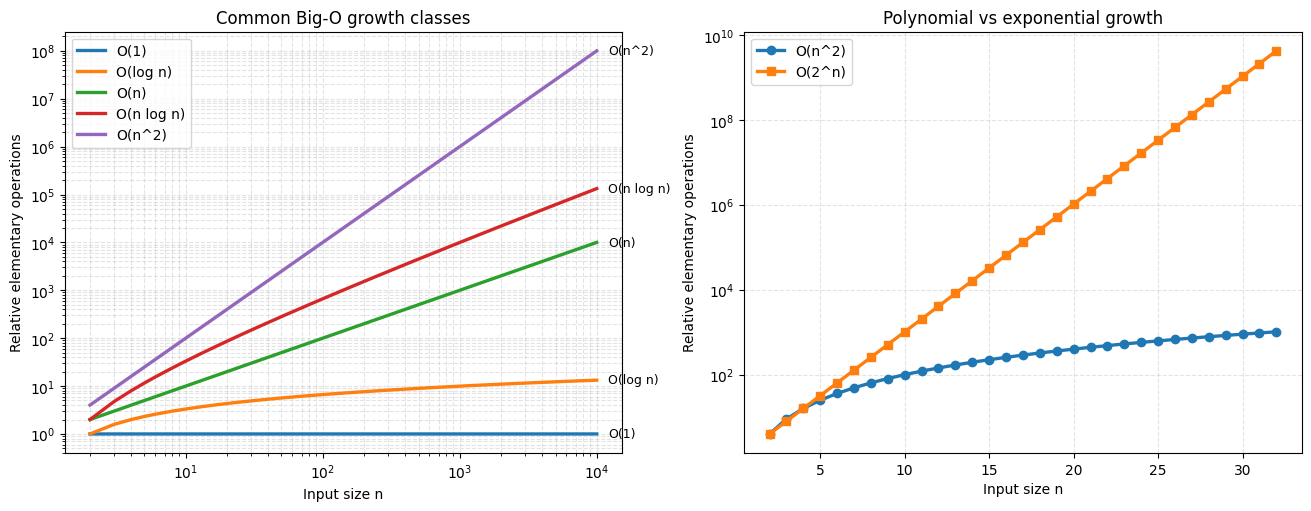

n      log2(n)      n      n log2(n)      n^2
10         3.32       10         33.22          100
100        6.64      100        664.39        10000
1000       9.97     1000       9965.78      1000000
10000     13.29    10000     132877.12    100000000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Use theoretical growth functions, not wall-clock timings.
n = np.arange(2, 10001)
log_n = np.log2(n)
curves = {
    "O(1)": np.ones_like(n, dtype=float),
    "O(log n)": log_n,
    "O(n)": n,
    "O(n log n)": n * log_n,
    "O(n^2)": n**2,
}

n_exp = np.arange(2, 33)
quadratic_small = n_exp**2
exponential_small = 2.0**n_exp

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax = axes[0]
for label, values in curves.items():
    ax.loglog(n, values, linewidth=2.4, label=label)
    ax.annotate(
        label,
        xy=(n[-1], values[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )
ax.set_title("Common Big-O growth classes")
ax.set_xlabel("Input size n")
ax.set_ylabel("Relative elementary operations")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(loc="upper left")

ax = axes[1]
ax.semilogy(n_exp, quadratic_small, linewidth=2.4, marker="o", label="O(n^2)")
ax.semilogy(n_exp, exponential_small, linewidth=2.4, marker="s", label="O(2^n)")
ax.set_title("Polynomial vs exponential growth")
ax.set_xlabel("Input size n")
ax.set_ylabel("Relative elementary operations")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(loc="upper left")

plt.show()

sample_n = np.array([10, 100, 1000, 10000])
print("n      log2(n)      n      n log2(n)      n^2")
for value in sample_n:
    print(
        f"{value:<6d} {np.log2(value):>8.2f} "
        f"{value:>8d} {value * np.log2(value):>13.2f} {value**2:>12d}"
    )


## Interpretation

On logarithmic scales, straight lines make orders of magnitude easier to compare: $O(n)$ grows faster than $O(\log n)$, $O(n \log n)$ lies between linear and quadratic growth, and $O(n^2)$ separates quickly as input size increases. The second plot shows why exponential algorithms often become infeasible even for moderate values of $n$: $2^n$ very soon exceeds any fixed polynomial.

A practical consequence is that optimizing constants is not a substitute for choosing a better complexity class. Halving the running time of an $O(n^2)$ algorithm helps, but changing the approach to an $O(n \log n)$ algorithm can completely change the scale of problems that can be solved.


## Exercises

1. For $n = 10^6$, compare $n$, $n \log_2 n$, and $n^2$ mentally. What practical difference is there between scanning a list, sorting it efficiently, and comparing all pairs?
2. Choose an algorithm from a course you know and identify which elementary operation dominates its cost. Then justify whether your analysis is worst case, average case, or amortized cost.
